In [1]:
import pandas as pd
import matplotlib.pyplot as plt

BIO_LIP_COLUMNS = [
"PDB ID",
"Receptor chain",
"Resolution. '-1.00' stands for lack of resolution information, e.g. for NMR",
"Binding site number code",
"Ligand_ID",
"Ligand_chain",
"Ligand serial number",
"    Binding site residues (with PDB residue numbering)",
"    Binding site residues (with residue re-numbered starting from 1)",
"Catalytic site residues (different sites are separated by ';') (with PDB residue numbering)",
"    Catalytic site residues (different sites are separated by ';') (with residue re-numbered starting from 1)",
"EC number",
"GO terms",
"Binding affinity by manual survey of the original literature. The information in '()' is the PubMed ID",
"Binding affinity provided by the Binding MOAD database. The information in '()' is the ligand information in Binding MOAD",
"Binding affinity provided by the PDBbind-CN database. The information in '()' is the ligand information in PDBbind-CN",
"Binding affinity provided by the BindingDB database",
"UniProt ID",
"PubMed ID",
"Residue sequence number of the ligand (field _atom_site.auth_seq_id in PDBx/mmCIF format)",
"Receptor sequence"]


In [2]:
df = pd.read_csv('/homes/hagayr/study/thesis/BioLiP_nr.txt', sep="\t", header=None, names=BIO_LIP_COLUMNS)


/tmp/ipykernel_3700/534871246.py:1: DtypeWarning: Columns (13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/homes/hagayr/study/thesis/BioLiP_nr.txt', sep="\t", header=None, names=BIO_LIP_COLUMNS)


## Filter relevant columns

In [3]:
relevant_columns = ["PDB ID", "Receptor chain", "Ligand_ID", "Ligand_chain"]
df = df[relevant_columns].astype('str')
df.shape


(76344, 4)

## Filter ligands with less than 2 proteins

In [4]:
# Count occurrences of values in the specified column
value_counts = df["Ligand_ID"].value_counts()

# Get the values that occur more than once
values_to_keep = value_counts[value_counts > 1].index

# Filter the DataFrame to keep rows where the value in the specified column occurs more than once
df = df[df["Ligand_ID"].isin(values_to_keep)]
df = df[df["Ligand_chain"]=='A']
df.shape


(32088, 4)

## Leave unique protein per ligand

In [15]:
filtered_df = df.groupby(["Ligand_ID", "PDB ID"]).apply(lambda x: x.loc[x['Receptor chain'].idxmin()])
filtered_df = df.groupby(["Ligand_ID", "PDB ID"]).apply(lambda x: x.loc[x['Ligand_chain'].idxmin()])
filtered_df.shape


/tmp/ipykernel_3700/4077791971.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df.groupby(["Ligand_ID", "PDB ID"]).apply(lambda x: x.loc[x['Receptor chain'].idxmin()])
/tmp/ipykernel_3700/4077791971.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df.groupby(["Ligand_ID", "PDB ID"]).apply(lambda x: x.loc[x['Ligand_chain'].idxmin()])


(22818, 4)

# plot ligand histogram

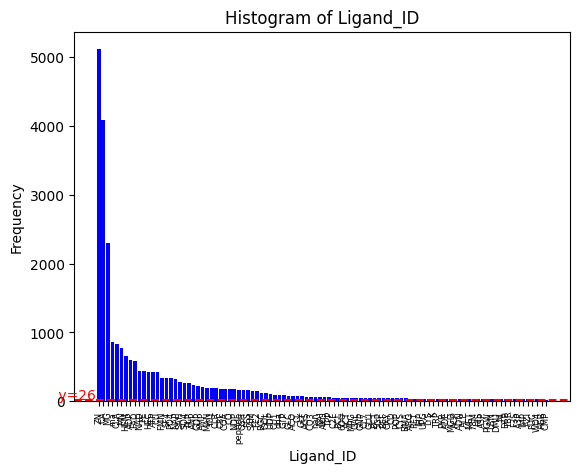

In [29]:
column_to_plot = "Ligand_ID"
value_counts = df[column_to_plot].value_counts()

# Plot the histogram
plt.bar(value_counts.index[:100], value_counts.values[:100], color='blue')
plt.xticks(fontsize=6)  # Adjust the font size as per your preference
# Extract the height of the last bar
last_bar_height = value_counts.values[:100][-1]

# Plot a horizontal line parallel to the x-axis at the height of the last bar
plt.axhline(y=last_bar_height, color='red', linestyle='--')
plt.text(-10, last_bar_height, f' y={last_bar_height}', color='red', fontsize=10)


# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=90)

# Add labels and title
plt.xlabel(column_to_plot)
plt.ylabel('Frequency')
plt.title('Histogram of {}'.format(column_to_plot))

# Show plot
plt.show()

In [32]:
value_counts = df["Ligand_ID"].value_counts()
# Example usage:
pairs_per_ligand = value_counts.apply(lambda x: x*(x-1)//2)
    
# Compute the total number of pairs
total_pairs = pairs_per_ligand.sum()
print("Total number of pairs:", total_pairs)

Total number of pairs: 26787548


## Cath relationthip between pairs

In [12]:
cath_chains = pd.read_csv('/homes/hagayr/study/thesis/cath-domain-list.txt',sep='\s+', names=['pdb_chain', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k'], skiprows=16)
cath_chains = cath_chains.set_index('pdb_chain')

In [33]:
def compare_rows(row1, row2):
    for i in range(len(row1)):
        if row1[i] != row2[i]:
            return i
    return i + 1

In [34]:
import itertools

matching_columns = []

missing_proteins, exist_proteins = set(), set()
for id in df["Ligand_ID"].unique():
    num_of_pairs = 0
    filtered_rows = df[df['Ligand_ID'] == id]
    
    unique_pairs = set()
    combinations = list(itertools.combinations(filtered_rows.iterrows(), 2))
    for row1, row2 in combinations:
        row1 = row1[1]
        row2 = row2[1]
        if row1['PDB ID'] != row2['PDB ID'] and (row1[0], row2[0]) not in  unique_pairs and (row2[0], row1[0]) not in  unique_pairs:
            unique_pairs.add((row1[0], row2[0]))
            idx1 = f"{row1['PDB ID']}{row1['Receptor chain']}00"
            idx2 = f"{row2['PDB ID']}{row2['Receptor chain']}00"
            if idx1 in missing_proteins or idx2 in missing_proteins:
                continue
            try:
                row1 = cath_chains.loc[idx1][:8]
            except KeyError:
                missing_proteins.add(idx1)
                continue
            exist_proteins.add(idx1)
            try:    
                row2 = cath_chains.loc[idx2][:8] 
            except KeyError:
                missing_proteins.add(idx2)
                continue
            exist_proteins.add(idx2)
            num_of_pairs +=1

  
            matching_columns.append(compare_rows(row1, row2))
            if num_of_pairs > 1000:
                break



/tmp/ipykernel_3700/4008202107.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if row1['PDB ID'] != row2['PDB ID'] and (row1[0], row2[0]) not in  unique_pairs and (row2[0], row1[0]) not in  unique_pairs:
/tmp/ipykernel_3700/4008202107.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  unique_pairs.add((row1[0], row2[0]))
/tmp/ipykernel_3700/957379781.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if row1[i] != row2[i]:


11943
5047
32937


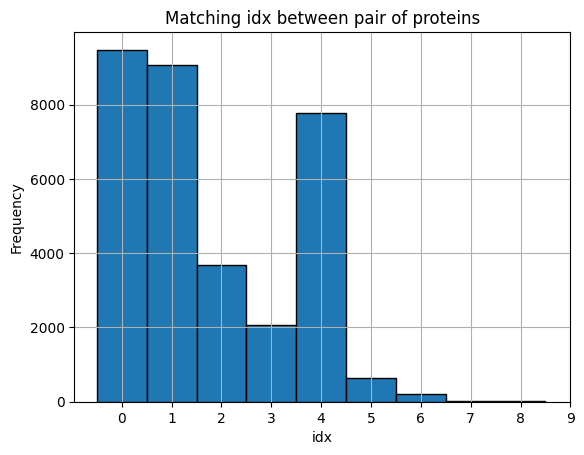

In [36]:
# Plot histogram

print(len(missing_proteins))
print(len(exist_proteins))
print(len(matching_columns))
plt.hist(matching_columns, bins=range(max(matching_columns) + 2), align='left', edgecolor='black')

plt.xlabel('idx')
plt.ylabel('Frequency')
plt.title('Matching idx between pair of proteins')
plt.xticks(range(max(matching_columns) + 2))
plt.grid(True)
plt.show()

In [9]:
import os
import itertools
import random


for id in df["Ligand_ID"].unique()[:1]:
# for id in ligands:
    # Filter the DataFrame to include only rows with the current ID value
    filtered_rows = df[df['Ligand_ID'] == id]
    
    # Define the file path for the current ID
    ligand_repo = os.path.join("/homes/hagayr/study/thesis/allignment_playgroud/alligned_structures", id)
    os.makedirs(ligand_repo, exist_ok=True)
  
    # Write the filtered rows to a separate file
    num_of_pairs = 1
    unique_pairs = set()
    pairs_file = os.path.join(ligand_repo, f"{id}.txt")
    with open(pairs_file, "w") as output_file:
        combinations = list(itertools.combinations(filtered_rows.iterrows(), 2))
        random.shuffle(combinations)
        for row1, row2 in combinations:
            row1 = row1[1]
            row2 = row2[1]
            if row1['PDB ID'] != row2['PDB ID'] and (row1[0], row2[0]) not in  unique_pairs and (row2[0], row1[0]) not in  unique_pairs:
                unique_pairs.add((row1[0], row2[0]))
                num_of_pairs +=1
                output_file.write(f"{row1['PDB ID']}:{row1['Receptor chain']} {row2['PDB ID']}:{row2['Receptor chain']}\n")
                if num_of_pairs > 20:
                    break

/tmp/ipykernel_10003/3713250300.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if row1['PDB ID'] != row2['PDB ID'] and (row1[0], row2[0]) not in  unique_pairs and (row2[0], row1[0]) not in  unique_pairs:
/tmp/ipykernel_10003/3713250300.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  unique_pairs.add((row1[0], row2[0]))
